# Behavioral Characterization of Large-Scale Network Traffic

### Feature Engineering, Dimensionality Reduction and Clustering

Objective:

Transform raw flow-level network features into a compact and interpretable representation suitable for behavioral traffic analysis.

Pipeline:

Raw Features
→ Feature Selection
→ Log Transformation
→ Standardization
→ Principal Component Analysis (PCA)
→ Behavioral Clustering
→ Cluster Interpretation

# Why Feature Engineering?

The original dataset contains a large number of network traffic features describing:

- Packet counts
- Byte counts
- Timing information
- TCP flags
- Flow statistics

Many of these features exhibit:

- Heavy-tailed distributions
- Extreme outliers
- Redundancy and correlation

Directly applying clustering on the raw feature space can produce misleading results.

The goal of this stage is to transform the data into a representation that better captures underlying traffic behavior.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
CSV_PATH = "Dataset-Unicauca-Version2-87Atts.csv"
sample = pd.read_csv(
    CSV_PATH
)
sample=sample.sample(n=100000,random_state=0)
sample.shape

(100000, 87)

# Sampling Strategy

The complete dataset contains approximately 3.57 million network flows.

Due to the computational cost of PCA and clustering on the full dataset, a random sample of 100,000 flows was selected for model fitting and exploratory analysis.

The full dataset was used during initial exploratory analysis to understand overall traffic characteristics and feature distributions.

In [79]:
sample.shape

(100000, 87)

# Removing Non-Behavioral Identifiers

Several columns uniquely identify network flows but do not describe traffic behavior.

Examples:

- Flow.ID
- Source.IP
- Destination.IP
- Timestamp
- Label

These features are removed because clustering should be driven by traffic characteristics rather than identifiers.

In [80]:
sample = sample.drop(columns=[
    'Flow.ID',
    'Source.IP',
    'Destination.IP',
    'Timestamp',
    'Label'    
])

In [81]:
sample.columns.tolist()

['Source.Port',
 'Destination.Port',
 'Protocol',
 'Flow.Duration',
 'Total.Fwd.Packets',
 'Total.Backward.Packets',
 'Total.Length.of.Fwd.Packets',
 'Total.Length.of.Bwd.Packets',
 'Fwd.Packet.Length.Max',
 'Fwd.Packet.Length.Min',
 'Fwd.Packet.Length.Mean',
 'Fwd.Packet.Length.Std',
 'Bwd.Packet.Length.Max',
 'Bwd.Packet.Length.Min',
 'Bwd.Packet.Length.Mean',
 'Bwd.Packet.Length.Std',
 'Flow.Bytes.s',
 'Flow.Packets.s',
 'Flow.IAT.Mean',
 'Flow.IAT.Std',
 'Flow.IAT.Max',
 'Flow.IAT.Min',
 'Fwd.IAT.Total',
 'Fwd.IAT.Mean',
 'Fwd.IAT.Std',
 'Fwd.IAT.Max',
 'Fwd.IAT.Min',
 'Bwd.IAT.Total',
 'Bwd.IAT.Mean',
 'Bwd.IAT.Std',
 'Bwd.IAT.Max',
 'Bwd.IAT.Min',
 'Fwd.PSH.Flags',
 'Bwd.PSH.Flags',
 'Fwd.URG.Flags',
 'Bwd.URG.Flags',
 'Fwd.Header.Length',
 'Bwd.Header.Length',
 'Fwd.Packets.s',
 'Bwd.Packets.s',
 'Min.Packet.Length',
 'Max.Packet.Length',
 'Packet.Length.Mean',
 'Packet.Length.Std',
 'Packet.Length.Variance',
 'FIN.Flag.Count',
 'SYN.Flag.Count',
 'RST.Flag.Count',
 'PSH.Flag.Co

In [82]:
y_protocol=sample['ProtocolName']

In [83]:
X=sample.drop(columns=['ProtocolName'])
X.shape

(100000, 81)

In [84]:
missing = (
    X.isnull()
     .sum()
     .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [85]:
inf_count = np.isinf(X.values).sum()

print(f"Infinite values found: {inf_count}")

Infinite values found: 0


# Infinite Value Audit

Certain network traffic features such as Flow.Bytes.s and Flow.Packets.s may theoretically contain infinite values when flow duration approaches zero.

An explicit audit was performed before preprocessing.

No infinite values were detected in the sampled dataset.

-----

# Feature Skewness Analysis

Network traffic metrics often follow heavy-tailed distributions.

Examples include:

- Flow Duration
- Packet Counts
- Throughput Metrics

Highly skewed features can dominate distance-based algorithms such as PCA and K-Means.

Skewness is measured to identify features that require transformation.

In [86]:
skewness = (
    X.skew()
     .sort_values(ascending=False)
)

skewness.head(30)

Total.Length.of.Fwd.Packets    100.089504
Subflow.Fwd.Bytes              100.089504
act_data_pkt_fwd                95.293316
Total.Fwd.Packets               89.566644
Subflow.Fwd.Packets             89.566644
Fwd.Header.Length               81.098726
Fwd.Header.Length.1             81.098726
Bwd.Header.Length               74.539269
Total.Length.of.Bwd.Packets     67.762114
Subflow.Bwd.Bytes               67.762114
Subflow.Bwd.Packets             63.948392
Total.Backward.Packets          63.948392
RST.Flag.Count                  41.133522
ECE.Flag.Count                  41.133522
Flow.Bytes.s                    34.596329
Min.Packet.Length               33.357861
Flow.IAT.Min                    31.708873
Active.Min                      29.770252
Protocol                        26.476196
Active.Std                      24.132526
Active.Mean                     22.701357
Fwd.Packet.Length.Min           18.648385
Active.Max                      16.064720
Bwd.Packet.Length.Min           14

# Logarithmic Transformation

Features with extreme positive skewness are transformed using:

log(1 + x)

This transformation:

- Compresses large outliers
- Preserves ordering
- Reduces variance imbalance
- Improves clustering stability

The transformation is applied only to highly skewed numerical features.

In [87]:
log_cols = skewness[
    skewness > 5
].index.tolist()

print(len(log_cols))
print(log_cols)

37
['Total.Length.of.Fwd.Packets', 'Subflow.Fwd.Bytes', 'act_data_pkt_fwd', 'Total.Fwd.Packets', 'Subflow.Fwd.Packets', 'Fwd.Header.Length', 'Fwd.Header.Length.1', 'Bwd.Header.Length', 'Total.Length.of.Bwd.Packets', 'Subflow.Bwd.Bytes', 'Subflow.Bwd.Packets', 'Total.Backward.Packets', 'RST.Flag.Count', 'ECE.Flag.Count', 'Flow.Bytes.s', 'Min.Packet.Length', 'Flow.IAT.Min', 'Active.Min', 'Protocol', 'Active.Std', 'Active.Mean', 'Fwd.Packet.Length.Min', 'Active.Max', 'Bwd.Packet.Length.Min', 'Bwd.Packets.s', 'FIN.Flag.Count', 'Bwd.IAT.Min', 'Fwd.Packet.Length.Max', 'Fwd.IAT.Min', 'Init_Win_bytes_backward', 'Packet.Length.Variance', 'Fwd.Packets.s', 'Flow.IAT.Mean', 'Flow.Packets.s', 'Bwd.IAT.Mean', 'Fwd.Packet.Length.Mean', 'Avg.Fwd.Segment.Size']


In [88]:
log_cols.remove('Init_Win_bytes_backward')

### Special Case: Init_Win_bytes_backward

This feature contains sentinel values (-1) representing unavailable measurements.

To avoid distortion during logarithmic transformation, the feature was excluded from the log-transform step.

In [89]:
X_log = X.copy()

for col in log_cols:
    X_log[col] = np.log1p(X_log[col])

In [90]:
new_skew = (
    X_log.skew()
         .sort_values(ascending=False)
)

new_skew.head(20)

RST.Flag.Count             41.133522
ECE.Flag.Count             41.133522
FIN.Flag.Count             12.066464
Init_Win_bytes_backward     6.005691
Idle.Std                    4.997794
Fwd.IAT.Mean                4.310676
Bwd.Packet.Length.Max       3.964662
Max.Packet.Length           3.691171
Fwd.Packet.Length.Std       3.343553
Bwd.Packet.Length.Min       3.322793
Bwd.IAT.Std                 3.054518
Average.Packet.Size         2.972515
Bwd.Packet.Length.Mean      2.970308
Avg.Bwd.Segment.Size        2.970308
Init_Win_bytes_forward      2.924780
Packet.Length.Mean          2.884095
Down.Up.Ratio               2.794697
Bwd.IAT.Min                 2.769451
Idle.Min                    2.693737
Fwd.IAT.Std                 2.600593
dtype: float64

In [91]:
new_skew.describe()

count    81.000000
mean      2.185752
std       7.104254
min     -24.331364
25%       0.000000
50%       1.430744
75%       2.410865
max      41.133522
dtype: float64

# Feature Standardization

The dataset contains variables measured on very different scales.

Examples:

- Packet Counts
- Durations
- Throughput
- Window Sizes

Standardization ensures that each feature contributes equally during PCA and clustering.

Features are transformed to:

Mean = 0
Standard Deviation = 1

In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [93]:
X_scaled = scaler.fit_transform(X_log)

# Principal Component Analysis (PCA)

The transformed feature space still contains substantial redundancy.

PCA is applied to:

- Reduce dimensionality
- Remove correlated information
- Preserve dominant traffic characteristics
- Improve clustering efficiency

The resulting principal components represent latent behavioral factors within network traffic.



In [94]:
from sklearn.decomposition import PCA
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

In [95]:
print(X_pca.shape)

(100000, 81)


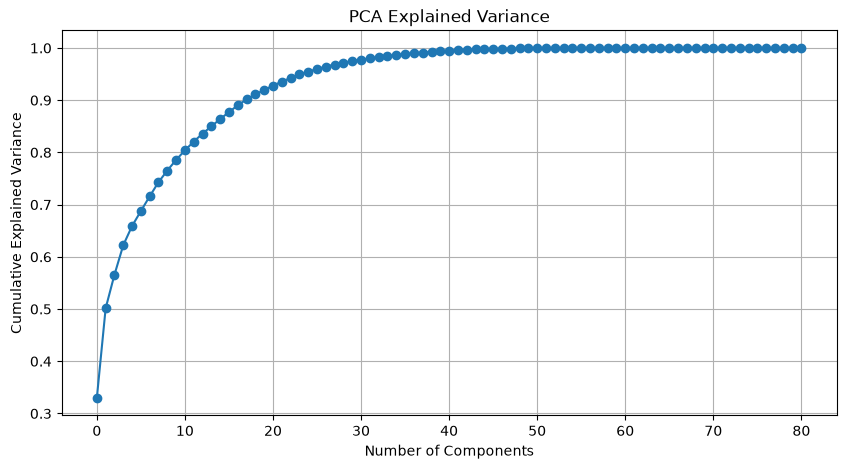

In [96]:
cum_var = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(10,5))
plt.plot(cum_var, marker='o')
plt.grid(True)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.show()

# Determining the Number of Components

The cumulative explained variance ratio is used to determine the number of principal components required to preserve information.

Thresholds examined:

- 90% Variance
- 95% Variance
- 99% Variance

The selected dimensionality should balance information retention and model simplicity.

In [97]:
n90 = np.argmax(cum_var >= 0.90) + 1
n95 = np.argmax(cum_var >= 0.95) + 1
n99 = np.argmax(cum_var >= 0.99) + 1

print("90% variance:", n90)
print("95% variance:", n95)
print("99% variance:", n99)

90% variance: 18
95% variance: 25
99% variance: 38


In [98]:
pca = PCA(n_components=18)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(100000, 18)


# Interpreting Principal Components

Principal components are examined through their feature loadings.

This analysis helps identify the latent factors driving variation in network traffic.

Rather than interpreting individual features, PCA reveals higher-level behavioral dimensions.

# Dominant Behavioral Factors

The first five principal components reveal the primary drivers of network behavior:

PC1 – Traffic Volume and Session Intensity

PC2 – Session Persistence and Temporal Dynamics

PC3 – Protocol and Connection Semantics

PC4 – Flow Directionality

PC5 – Burstiness and Packet Timing

Together, these components provide a compact representation of traffic behavior that is more informative than protocol labels alone.

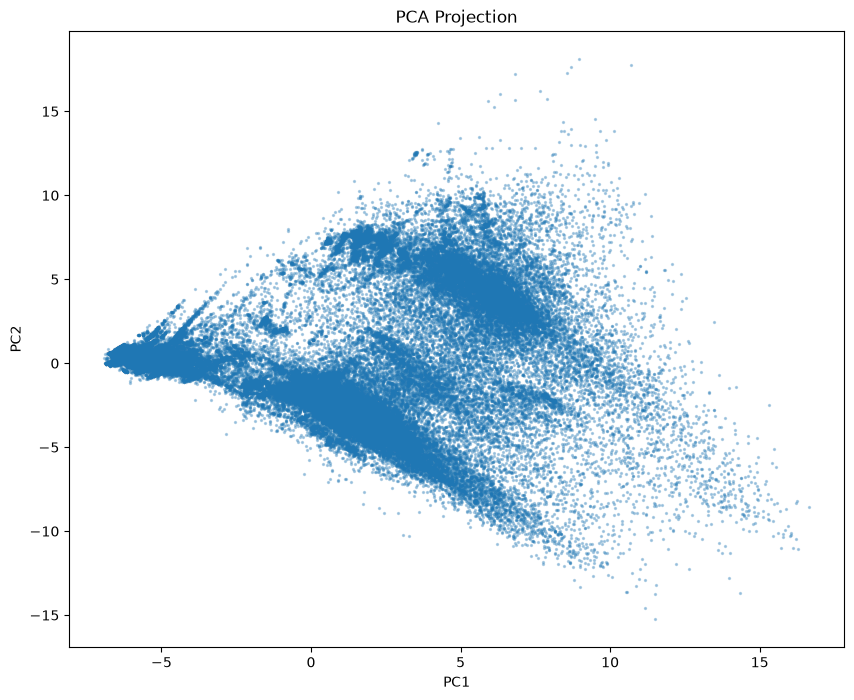

In [99]:
pca2 = PCA(n_components=2)

X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    s=2,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")

plt.show()

# Behavioral Clustering

The reduced PCA representation is used to identify groups of flows exhibiting similar behavior.

The objective is not to recover protocol labels.

Instead, clustering aims to discover:

- Traffic archetypes
- Communication patterns
- Behavioral similarities

that may span multiple applications and protocols.

In [100]:
from sklearn.cluster import MiniBatchKMeans
inertias = []
for k in range(2,16):
    kmeans=MiniBatchKMeans(n_clusters=k,random_state=0,batch_size=10000)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

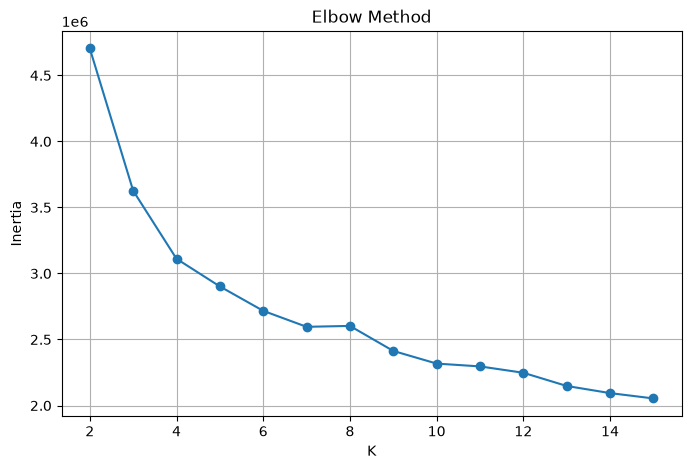

In [101]:
plt.figure(figsize=(8,5))
plt.plot(range(2,16), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# Selecting the Number of Clusters

The Elbow Method is used to evaluate clustering performance across multiple values of K.

The selected value should balance:

- Cluster compactness
- Interpretability
- Behavioral separation

In [102]:
kmeans=MiniBatchKMeans(n_clusters=7,random_state=0,batch_size=10000)
kmeans.fit(X_pca)

clusters=kmeans.fit_predict(X_pca)

# Cluster Profiling

Clusters are analyzed using:

- Median feature values
- Protocol distributions
- PCA component scores

The goal is to understand the behavioral characteristics represented by each cluster.

In [103]:
cluster_df = pd.DataFrame({
    'Cluster': clusters,
    'ProtocolName': y_protocol
})

In [104]:
pd.crosstab(
    cluster_df['Cluster'],
    cluster_df['ProtocolName']
)

ProtocolName,AMAZON,APPLE,APPLE_ICLOUD,APPLE_ITUNES,BITTORRENT,CITRIX_ONLINE,CLOUDFLARE,CNN,CONTENT_FLASH,DEEZER,...,TWITTER,UBUNTUONE,UNENCRYPED_JABBER,UPNP,WAZE,WHATSAPP,WIKIPEDIA,WINDOWS_UPDATE,YAHOO,YOUTUBE
Cluster,,,,,,,,,,,,,,,,,,,,,
0,166,0,0,0,0,1,14,0,0,0,...,19,0,0,0,0,26,0,3,16,184
1,81,5,0,6,0,0,32,0,4,0,...,33,2,0,0,0,12,7,438,18,1019
2,119,23,0,4,0,0,9,1,0,1,...,72,0,0,0,0,16,13,137,97,607
3,1304,76,27,10,1,0,157,1,200,0,...,226,5,0,0,0,33,13,261,356,1608
4,549,80,15,13,0,0,178,0,46,0,...,82,0,0,2,2,22,8,110,106,725
5,161,10,3,0,0,0,15,0,0,0,...,35,0,1,0,0,22,5,22,44,366
6,69,1,0,1,0,0,2,0,0,0,...,39,0,0,0,0,5,2,6,4,212


In [105]:
for c in sorted(cluster_df['Cluster'].unique()):
    print(f"\nCluster {c}")
    print(
        cluster_df[
            cluster_df['Cluster']==c
        ]['ProtocolName']
        .value_counts()
        .head(10)
    )


Cluster 0
ProtocolName
HTTP_PROXY      4150
GOOGLE          2886
SSL             1039
HTTP             658
DROPBOX          214
YOUTUBE          184
AMAZON           166
GMAIL            144
HTTP_CONNECT     100
SKYPE             76
Name: count, dtype: int64

Cluster 1
ProtocolName
HTTP_PROXY        1323
YOUTUBE           1019
GOOGLE             897
SSL                847
HTTP               717
HTTP_CONNECT       666
WINDOWS_UPDATE     438
MICROSOFT          122
AMAZON              81
GMAIL               48
Name: count, dtype: int64

Cluster 2
ProtocolName
HTTP              8924
HTTP_PROXY        4317
GOOGLE            3870
HTTP_CONNECT      2411
SSL                836
YOUTUBE            607
MICROSOFT          251
GMAIL              149
WINDOWS_UPDATE     137
SKYPE              136
Name: count, dtype: int64

Cluster 3
ProtocolName
GOOGLE          8559
SSL             4809
HTTP_CONNECT    4121
HTTP            4004
HTTP_PROXY      3853
YOUTUBE         1608
AMAZON          1304
MICROSOFT

In [106]:
cluster_stats = pd.DataFrame(X_log)

cluster_stats['Cluster'] = clusters

cluster_stats.groupby('Cluster')[
    [
        'Flow.Duration',
        'Flow.Bytes.s',
        'Flow.Packets.s',
        'Average.Packet.Size'
    ]
].median()

,Flow.Duration,Flow.Bytes.s,Flow.Packets.s,Average.Packet.Size
Cluster,,,,
0,104340236.0,3.818216,0.327010,95.841270
1,7544395.0,10.762727,3.776016,1041.279167
2,287.0,11.032575,9.161655,9.000000
3,1075879.5,8.133011,3.071336,197.015152
4,231.0,0.000000,9.332597,0.000000
5,90278620.0,4.843850,0.497037,207.137931
6,90011110.0,0.854808,0.105357,11.625000


In [107]:
cluster_stats[
    cluster_stats['Cluster']==4
][
    ['Flow.Duration',
     'Average.Packet.Size',
     'Total.Fwd.Packets',
     'Total.Backward.Packets']
].head()

,Flow.Duration,Average.Packet.Size,Total.Fwd.Packets,Total.Backward.Packets
3500813,115,0.000000,0.693147,0.693147
2730956,107,0.000000,0.693147,0.693147
77534,153649,0.000000,0.693147,0.693147
2261468,47061,1.947368,2.944439,0.693147
2916207,58,0.000000,0.693147,0.693147


In [108]:
cluster_stats[
    cluster_stats['Cluster']==4
][
[
'FIN.Flag.Count',
'SYN.Flag.Count',
'RST.Flag.Count',
'ACK.Flag.Count'
]
].median()

FIN.Flag.Count    0.0
SYN.Flag.Count    0.0
RST.Flag.Count    0.0
ACK.Flag.Count    1.0
dtype: float64

In [109]:
cluster_stats['Cluster'].value_counts().sort_index()

Cluster
0     9763
1     6371
2    22289
3    32010
4    15678
5     7683
6     6206
Name: count, dtype: int64

In [110]:
cluster_stats.groupby('Cluster').median()

,Source.Port,Destination.Port,Protocol,Flow.Duration,Total.Fwd.Packets,Total.Backward.Packets,Total.Length.of.Fwd.Packets,Total.Length.of.Bwd.Packets,Fwd.Packet.Length.Max,Fwd.Packet.Length.Min,...,min_seg_size_forward,Active.Mean,Active.Std,Active.Max,Active.Min,Idle.Mean,Idle.Std,Idle.Max,Idle.Min,L7Protocol
Cluster,,,,,,,,,,,,,,,,,,,,,
0,3128.0,39042.0,1.94591,104340236.0,2.944439,2.708050,7.527794,6.711740,6.077642,1.94591,...,32.0,12.202019,11.272597,12.802761,10.620522,25898774.50,1.960398e+06,29124031.0,20862000.0,126.0
1,50546.0,3128.0,1.94591,7544395.0,4.343805,4.727388,7.867106,11.934500,6.502790,0.00000,...,20.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
2,3128.0,3128.0,1.94591,287.0,1.098612,0.693147,2.564949,0.000000,1.945910,1.94591,...,20.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
3,50400.5,443.0,1.94591,1075879.5,2.302585,2.302585,6.962243,7.451242,6.249975,0.00000,...,32.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
4,45201.0,443.0,1.94591,231.0,0.693147,0.693147,0.000000,0.000000,0.000000,0.00000,...,32.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,124.0
5,51250.0,3128.0,1.94591,90278620.0,3.044522,3.295837,7.933438,8.552367,6.697034,0.00000,...,20.0,12.896205,11.687716,13.311242,11.528572,39820576.00,2.943898e+04,45002212.0,32638882.0,126.0
6,50849.0,3128.0,1.94591,90011110.0,1.609438,1.791759,3.610918,2.944439,1.945910,1.94591,...,20.0,5.361292,3.787219,5.631212,4.653960,44998511.75,7.710292e+03,45005563.0,44993194.0,126.0


In [111]:
features = [
    'Flow.Duration',
    'Flow.Bytes.s',
    'Flow.Packets.s',
    'Average.Packet.Size',
    'Flow.IAT.Mean',
    'Flow.IAT.Std',
    'Total.Fwd.Packets',
    'Total.Backward.Packets'
]

cluster_stats.groupby('Cluster')[features].median()

,Flow.Duration,Flow.Bytes.s,Flow.Packets.s,Average.Packet.Size,Flow.IAT.Mean,Flow.IAT.Std,Total.Fwd.Packets,Total.Backward.Packets
Cluster,,,,,,,,
0,104340236.0,3.818216,0.327010,95.841270,14.797144,8.371318e+06,2.944439,2.708050
1,7544395.0,10.762727,3.776016,1041.279167,10.067203,1.717672e+05,4.343805,4.727388
2,287.0,11.032575,9.161655,9.000000,5.192957,0.000000e+00,1.098612,0.693147
3,1075879.5,8.133011,3.071336,197.015152,10.863611,1.394628e+05,2.302585,2.302585
4,231.0,0.000000,9.332597,0.000000,5.010635,0.000000e+00,0.693147,0.693147
5,90278620.0,4.843850,0.497037,207.137931,14.274180,7.878167e+06,3.044522,3.295837
6,90011110.0,0.854808,0.105357,11.625000,16.118242,1.837023e+07,1.609438,1.791759


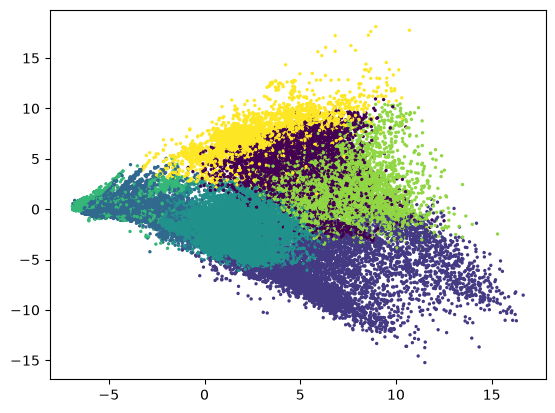

In [112]:
plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    s=2
)

In [113]:
cluster_stats.groupby('Cluster').median()

,Source.Port,Destination.Port,Protocol,Flow.Duration,Total.Fwd.Packets,Total.Backward.Packets,Total.Length.of.Fwd.Packets,Total.Length.of.Bwd.Packets,Fwd.Packet.Length.Max,Fwd.Packet.Length.Min,...,min_seg_size_forward,Active.Mean,Active.Std,Active.Max,Active.Min,Idle.Mean,Idle.Std,Idle.Max,Idle.Min,L7Protocol
Cluster,,,,,,,,,,,,,,,,,,,,,
0,3128.0,39042.0,1.94591,104340236.0,2.944439,2.708050,7.527794,6.711740,6.077642,1.94591,...,32.0,12.202019,11.272597,12.802761,10.620522,25898774.50,1.960398e+06,29124031.0,20862000.0,126.0
1,50546.0,3128.0,1.94591,7544395.0,4.343805,4.727388,7.867106,11.934500,6.502790,0.00000,...,20.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
2,3128.0,3128.0,1.94591,287.0,1.098612,0.693147,2.564949,0.000000,1.945910,1.94591,...,20.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
3,50400.5,443.0,1.94591,1075879.5,2.302585,2.302585,6.962243,7.451242,6.249975,0.00000,...,32.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,126.0
4,45201.0,443.0,1.94591,231.0,0.693147,0.693147,0.000000,0.000000,0.000000,0.00000,...,32.0,0.000000,0.000000,0.000000,0.000000,0.00,0.000000e+00,0.0,0.0,124.0
5,51250.0,3128.0,1.94591,90278620.0,3.044522,3.295837,7.933438,8.552367,6.697034,0.00000,...,20.0,12.896205,11.687716,13.311242,11.528572,39820576.00,2.943898e+04,45002212.0,32638882.0,126.0
6,50849.0,3128.0,1.94591,90011110.0,1.609438,1.791759,3.610918,2.944439,1.945910,1.94591,...,20.0,5.361292,3.787219,5.631212,4.653960,44998511.75,7.710292e+03,45005563.0,44993194.0,126.0


In [114]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_log.columns,
    columns=[f'PC{i+1}' for i in range(18)]
)

In [115]:
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
Source.Port,0.029656,-0.048505,-0.282712,-0.073318,0.062212,0.007572,0.124867,-0.134147,-0.131187,-0.371803,-0.161471,-0.019123,0.196459,0.075644,0.019535,-0.007738,0.051338,0.141489
Destination.Port,-0.028181,0.066336,0.301885,0.085031,-0.092459,-0.007317,-0.140450,0.103282,0.051347,0.213965,0.218148,0.005640,-0.013123,-0.251885,-0.136096,0.129158,-0.020602,-0.091712
Protocol,0.007912,-0.002181,0.017203,0.012513,0.023506,-0.009523,0.020846,0.018654,-0.116292,0.032454,-0.069674,0.301127,0.470658,-0.340097,0.592288,-0.298223,-0.196054,-0.136318
Flow.Duration,0.143516,0.172910,0.060087,-0.050007,0.055799,-0.001989,-0.016981,0.016351,-0.114805,0.021532,0.064046,0.048542,-0.011775,0.042538,0.041465,0.061742,0.048716,0.068397
Total.Fwd.Packets,0.169899,-0.084486,0.116523,0.001262,0.125408,-0.004160,-0.085353,0.039364,-0.199180,0.035977,-0.000215,0.127700,0.001902,0.066716,-0.088688,-0.026584,0.008976,0.058122


# Interpretation of Principal Components

## PC1 — Traffic Volume / Session Intensity

Top Features:
- Total.Length.of.Fwd.Packets
- Subflow.Fwd.Bytes
- Total.Fwd.Packets
- Total.Backward.Packets
- Packet.Length.Variance

Interpretation:

PC1 is primarily associated with the amount of data exchanged during a flow.

High PC1 values correspond to:
- Larger payload volumes
- More packets
- Higher traffic intensity

This component represents overall traffic volume and session intensity.

In [116]:
loadings['PC1'].sort_values(
    key=abs,
    ascending=False
).head(20)

Total.Length.of.Fwd.Packets    0.177299
Subflow.Fwd.Bytes              0.177299
Packet.Length.Variance         0.175437
Bwd.IAT.Mean                   0.172760
Fwd.Header.Length              0.172757
Fwd.Header.Length.1            0.172757
Subflow.Bwd.Packets            0.170021
Total.Backward.Packets         0.170021
Total.Fwd.Packets              0.169899
Subflow.Fwd.Packets            0.169899
Fwd.Packet.Length.Max          0.168046
Subflow.Bwd.Bytes              0.167587
Total.Length.of.Bwd.Packets    0.167587
act_data_pkt_fwd               0.163547
Bwd.Header.Length              0.158801
Fwd.Packets.s                 -0.158132
Flow.Packets.s                -0.157819
Flow.IAT.Mean                  0.151944
URG.Flag.Count                -0.149963
Avg.Fwd.Segment.Size           0.149285
Name: PC1, dtype: float64

## PC2 — Session Persistence / Temporal Dynamics

Top Features:
- Idle.Max
- Idle.Mean
- Flow.IAT.Std
- Flow.Duration
- Bwd.IAT.Max

Interpretation:

PC2 is primarily associated with timing characteristics.

High PC2 values correspond to:
- Long-lived sessions
- Larger idle periods
- Greater inter-arrival time variability

This component captures session persistence and temporal behavior.

In [117]:
loadings['PC2'].sort_values(
    key=abs,
    ascending=False
).head(20)

Idle.Max                  0.203489
Flow.IAT.Std              0.201461
Idle.Mean                 0.200865
Bwd.IAT.Max               0.187262
Idle.Min                  0.184944
Bwd.IAT.Std               0.183431
Fwd.IAT.Mean              0.178798
Fwd.IAT.Max               0.178230
Flow.IAT.Max              0.173697
Flow.Duration             0.172910
Fwd.IAT.Total             0.171655
Bwd.IAT.Total             0.168748
Fwd.IAT.Std               0.168222
Packet.Length.Std        -0.166796
PSH.Flag.Count           -0.161578
ACK.Flag.Count            0.159415
Bwd.Packet.Length.Std    -0.157764
Flow.Bytes.s             -0.155707
Avg.Bwd.Segment.Size     -0.153555
Bwd.Packet.Length.Mean   -0.153555
Name: PC2, dtype: float64

## PC3 — Protocol / Connection Semantics

Top Features:
- Destination.Port
- Source.Port
- SYN.Flag.Count
- ACK.Flag.Count
- Min.Packet.Length

Interpretation:

PC3 is associated with protocol-level communication patterns and connection behavior.

This component captures transport and application-level communication semantics.

In [118]:
loadings['PC3'].sort_values(
    key=abs,
    ascending=False
).head(20)

Destination.Port         0.301885
Min.Packet.Length        0.293742
Source.Port             -0.282712
Fwd.Packet.Length.Min    0.270119
Fwd.PSH.Flags            0.228234
SYN.Flag.Count           0.228234
ACK.Flag.Count           0.227461
PSH.Flag.Count          -0.223020
Flow.Bytes.s             0.220408
Bwd.Packet.Length.Min    0.190465
Fwd.Packets.s            0.162302
Flow.Packets.s           0.156653
Flow.IAT.Mean           -0.156257
Fwd.IAT.Min             -0.140964
act_data_pkt_fwd         0.131251
min_seg_size_forward    -0.126730
L7Protocol              -0.123994
Subflow.Fwd.Packets      0.116523
Total.Fwd.Packets        0.116523
Average.Packet.Size      0.115693
Name: PC3, dtype: float64

## PC4 — Flow Directionality

Top Features:
- Fwd.Packet.Length.Mean
- Avg.Fwd.Segment.Size
- Bwd.Packet.Length.Mean
- Bwd.Packet.Length.Max

Interpretation:

PC4 differentiates flows based on the direction of data transfer.

High and low values indicate different balances between forward and backward traffic.

In [119]:
loadings['PC4'].sort_values(
    key=abs,
    ascending=False
).head(20)

Fwd.Packet.Length.Mean         0.292345
Avg.Fwd.Segment.Size           0.292345
Bwd.Packet.Length.Max         -0.268188
Bwd.Packet.Length.Mean        -0.267148
Avg.Bwd.Segment.Size          -0.267148
Fwd.Packet.Length.Max          0.217436
Fwd.Packet.Length.Std          0.201692
Max.Packet.Length             -0.199784
Subflow.Fwd.Bytes              0.198870
Total.Length.of.Fwd.Packets    0.198870
Bwd.Packet.Length.Std         -0.188761
URG.Flag.Count                -0.168781
Down.Up.Ratio                 -0.156094
Bwd.Packets.s                 -0.155584
Packet.Length.Mean            -0.155056
Average.Packet.Size           -0.144182
Packet.Length.Std             -0.141512
PSH.Flag.Count                 0.128677
ACK.Flag.Count                -0.115025
Packet.Length.Variance         0.104894
Name: PC4, dtype: float64


## PC5 — Burstiness and Packet Timing

Top Features:
- min_seg_size_forward
- Fwd.IAT.Min
- Bwd.IAT.Min
- Min.Packet.Length

Interpretation:

PC5 captures fine-scale packet timing behavior and burst communication patterns.

In [120]:
loadings['PC5'].sort_values(
    key=abs,
    ascending=False
).head(20)

min_seg_size_forward      0.311882
Fwd.IAT.Min              -0.305551
Bwd.IAT.Min              -0.227420
Min.Packet.Length        -0.225211
Fwd.IAT.Mean             -0.221518
Fwd.Packet.Length.Min    -0.203795
Flow.Bytes.s             -0.185937
Flow.IAT.Std             -0.177964
Avg.Bwd.Segment.Size     -0.165753
Bwd.Packet.Length.Mean   -0.165753
Bwd.Packet.Length.Std    -0.164488
Active.Std                0.161356
Bwd.Header.Length         0.154165
Average.Packet.Size      -0.153847
Fwd.Header.Length         0.151027
Fwd.Header.Length.1       0.151027
Packet.Length.Std        -0.149474
Bwd.Packets.s             0.145090
Packet.Length.Mean       -0.141963
Bwd.Packet.Length.Min    -0.140764
Name: PC5, dtype: float64

# Interpretation Scope

A total of 18 principal components were retained, preserving approximately 90% of the total variance present in the original feature space.

While all 18 components contribute to variance preservation and are used for subsequent clustering, only the first five principal components are interpreted in detail.

The first five components capture the most dominant and interpretable dimensions of network traffic behavior, including:

- Traffic Volume and Session Intensity
- Session Persistence and Temporal Dynamics
- Protocol and Connection Semantics
- Flow Directionality
- Burstiness and Packet Timing

The remaining components explain progressively smaller portions of variance and are primarily associated with more specialized effects such as TCP flag combinations, protocol-specific characteristics, window-size behavior, and fine-grained timing variations.

These later components provide additional detail and refinement of the dominant behavioral patterns rather than introducing entirely new behavioral dimensions. Therefore, interpretation is focused on the first five principal components to maintain clarity while capturing the most meaningful structure present in the traffic data.

In [121]:
for pc in loadings.columns:
    print("\n" + "="*60)
    print(pc)
    print("="*60)

    print(
        loadings[pc]
        .sort_values(key=abs, ascending=False)
        .head(10)
    )


PC1
Total.Length.of.Fwd.Packets    0.177299
Subflow.Fwd.Bytes              0.177299
Packet.Length.Variance         0.175437
Bwd.IAT.Mean                   0.172760
Fwd.Header.Length              0.172757
Fwd.Header.Length.1            0.172757
Subflow.Bwd.Packets            0.170021
Total.Backward.Packets         0.170021
Total.Fwd.Packets              0.169899
Subflow.Fwd.Packets            0.169899
Name: PC1, dtype: float64

PC2
Idle.Max         0.203489
Flow.IAT.Std     0.201461
Idle.Mean        0.200865
Bwd.IAT.Max      0.187262
Idle.Min         0.184944
Bwd.IAT.Std      0.183431
Fwd.IAT.Mean     0.178798
Fwd.IAT.Max      0.178230
Flow.IAT.Max     0.173697
Flow.Duration    0.172910
Name: PC2, dtype: float64

PC3
Destination.Port         0.301885
Min.Packet.Length        0.293742
Source.Port             -0.282712
Fwd.Packet.Length.Min    0.270119
Fwd.PSH.Flags            0.228234
SYN.Flag.Count           0.228234
ACK.Flag.Count           0.227461
PSH.Flag.Count          -0.223020
F

In [122]:
pc_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

pc_df['Cluster'] = clusters

cluster_pc = pc_df.groupby('Cluster').mean()

cluster_pc

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
Cluster,,,,,,,,,,,,,,,,,,
0,5.289141,4.182978,2.516614,0.752897,1.145314,-0.431219,0.515677,0.716066,0.181701,-0.011085,-0.495282,-0.058097,-0.142887,-0.041058,-0.042533,0.189755,-0.006710,-0.303789
1,6.520793,-6.094338,1.392031,-3.792143,-0.859378,-0.286459,-0.182893,0.631646,-0.398771,-0.038967,0.114056,0.338918,-0.027850,0.226141,-0.148248,-0.068521,0.005817,-0.090673
2,-5.094373,0.283360,1.875235,0.188068,-0.926106,0.372642,0.119371,-0.665748,-0.166345,-0.214052,-0.176825,-0.019872,0.005911,-0.056765,-0.009579,0.150185,-0.101759,-0.049520
3,1.296342,-2.545419,-1.302376,1.577488,-0.076361,-0.063769,0.146930,0.022023,0.166660,0.071828,-0.005069,0.077677,-0.062446,-0.115306,0.017661,0.130180,-0.038832,0.018456
4,-5.759209,0.569233,-1.069628,-1.783230,1.559583,-0.373417,-0.362041,0.793531,0.156883,0.218221,0.106562,-0.203853,0.169829,0.238095,0.055228,-0.304903,0.256577,0.007826
5,6.859206,2.540281,-0.692252,-0.594546,0.749996,1.005991,-0.972452,-1.632885,0.035717,0.170811,-0.170784,-0.728067,0.256835,-0.250855,-0.017971,-0.325394,0.043688,0.280124
6,2.652968,7.204355,-1.846310,-0.862496,-2.067944,-0.339049,0.308443,0.519367,-0.579201,-0.307017,1.265509,0.830521,-0.192756,0.340114,0.045139,-0.265924,-0.131921,0.287087


# Cluster Interpretation

Clusters were interpreted using three sources of evidence:

1. Median feature values
2. Protocol distribution within each cluster
3. Average principal component scores

The objective is not to recover protocol labels, but to identify distinct behavioral traffic archetypes.

Cluster labels are therefore descriptive interpretations based on observed traffic characteristics rather than ground-truth categories.

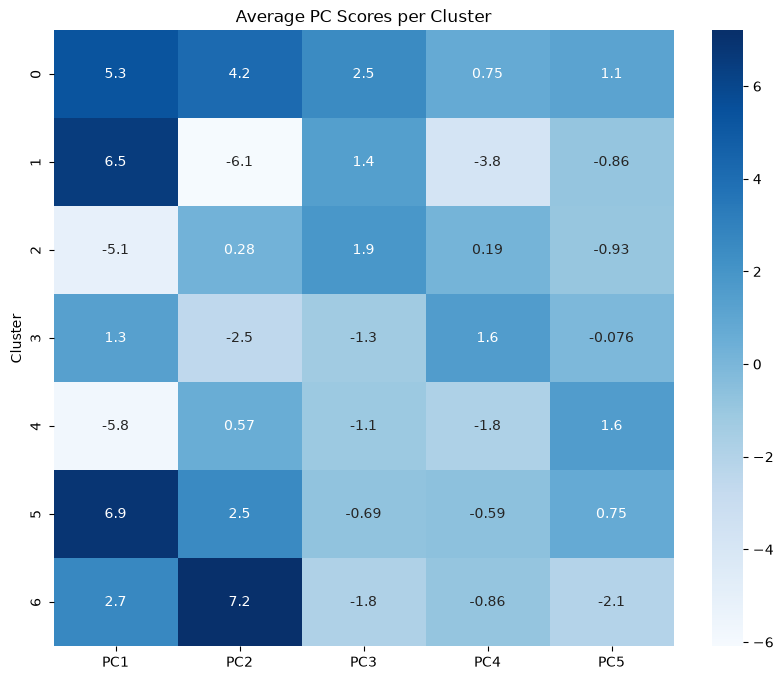

In [143]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cluster_pc.iloc[:, :5],
    annot=True,
    cmap='Blues',
    center=0.5
)

plt.title('Average PC Scores per Cluster')
plt.show()

In [124]:
radar_data = cluster_pc[['PC1','PC2','PC3','PC4','PC5']]

radar_data = (
    radar_data - radar_data.min()
) / (
    radar_data.max() - radar_data.min()
)

radar_data

,PC1,PC2,PC3,PC4,PC5
Cluster,,,,,
0,0.875574,0.772806,1.000000,0.846434,0.885799
1,0.973181,0.000000,0.742241,0.000000,0.333165
2,0.052688,0.479573,0.852993,0.741245,0.314770
3,0.559147,0.266862,0.124672,1.000000,0.549019
4,0.000000,0.501070,0.178019,0.374125,1.000000
5,1.000000,0.649283,0.264515,0.595496,0.776821
6,0.666659,1.000000,0.000000,0.545595,0.000000


In [125]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_radar(cluster_id):

    values = radar_data.loc[cluster_id].values

    labels = [
        'Volume',
        'Persistence',
        'Protocol',
        'Directionality',
        'Burstiness'
    ]

    angles = np.linspace(
        0,
        2*np.pi,
        len(labels),
        endpoint=False
    )

    values = np.concatenate([values,[values[0]]])
    angles = np.concatenate([angles,[angles[0]]])

    plt.figure(figsize=(6,6))

    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    plt.title(f'Cluster {cluster_id}')

    plt.show()


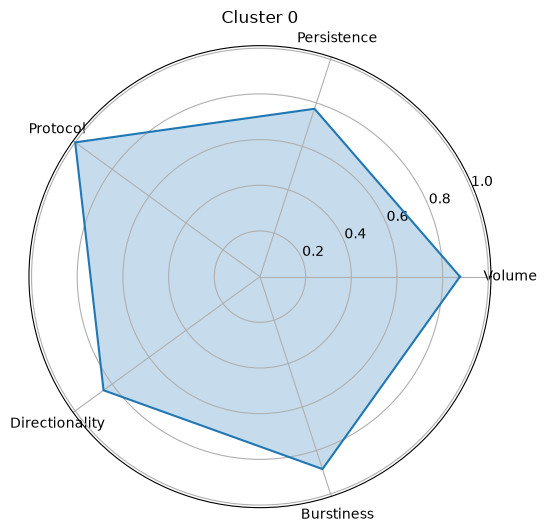

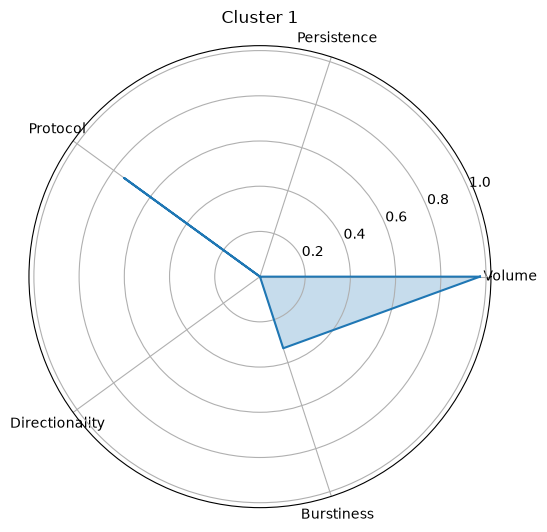

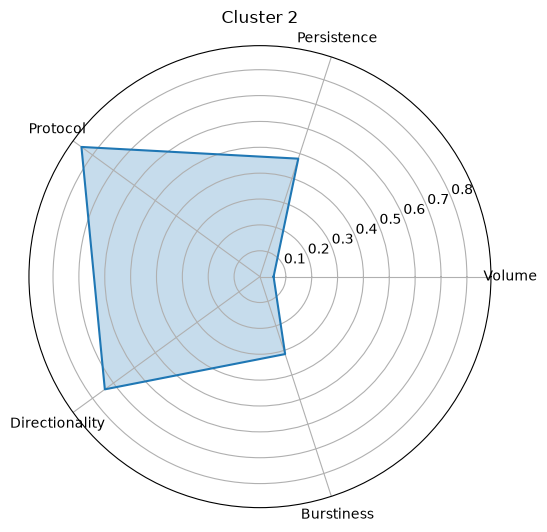

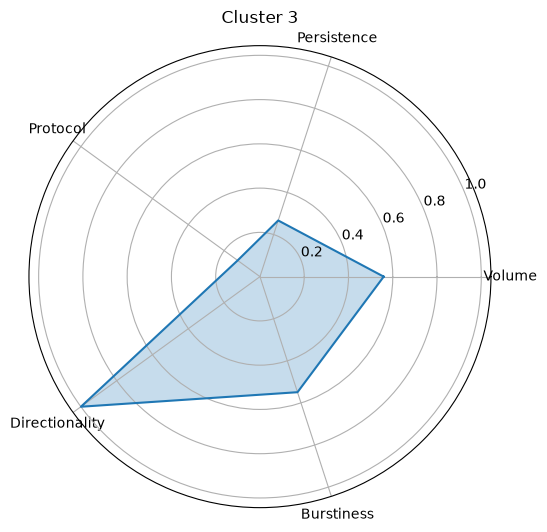

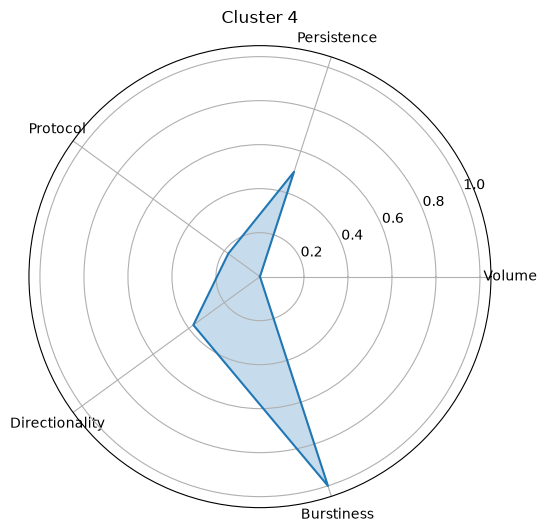

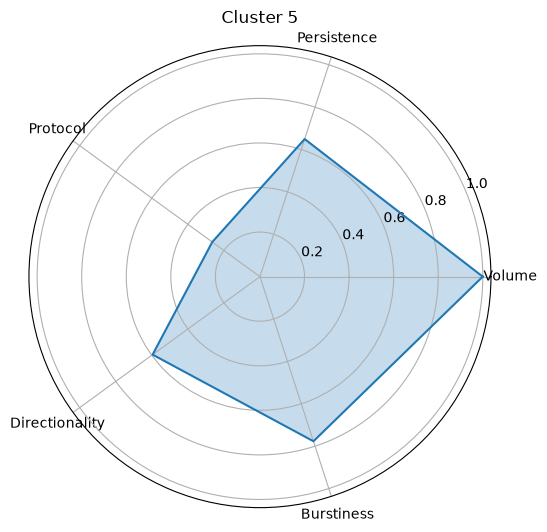

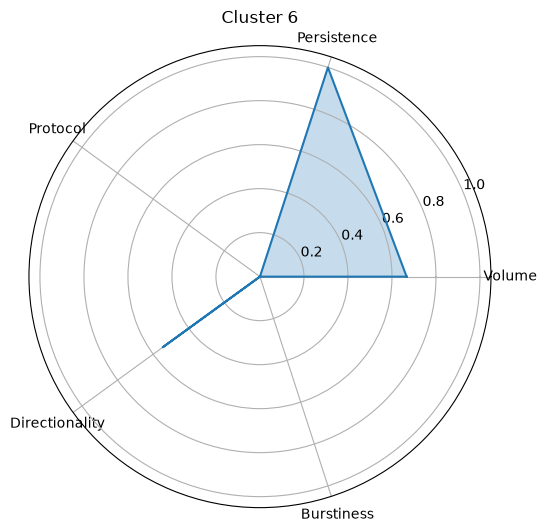

In [126]:
for i in radar_data.index:
    plot_cluster_radar(i)

Cluster 0
## Cluster 0 — Persistent High-Volume Proxy Sessions

Evidence:

- Very high PC1 (Traffic Volume)
- High PC2 (Session Persistence)
- Long flow durations
- Large packet and byte counts
- Dominated by proxy-related traffic

Interpretation:

This cluster represents long-lived, high-volume communication sessions characterized by sustained data exchange over extended periods.
Cluster 1
## Cluster 1 — Bulk Transfer Traffic

Evidence:

- Extremely high PC1 (Traffic Volume)
- Strong negative PC2 (short-lived sessions)
- Largest average packet sizes
- High throughput

Interpretation:

This cluster represents high-volume data transfers occurring over relatively short durations, consistent with downloads, uploads, and large file transfers.
Cluster 2
## Cluster 2 — Micro-Transaction Traffic

Evidence:

- Strongly negative PC1
- Very short durations
- Small packet counts
- Low payload volume

Interpretation:

This cluster represents lightweight communication events involving minimal data exchange and short-lived flows.
Cluster 3
## Cluster 3 — Interactive Application Traffic

Evidence:

- Moderate PC1 values
- Moderate durations
- Balanced forward and backward communication
- Largest cluster by population

Interpretation:

This cluster represents typical user-driven application activity involving frequent bidirectional communication.
Cluster 4
## Cluster 4 — Control / Acknowledgement Traffic

Evidence:

- Strongly negative PC1
- Near-zero packet sizes
- ACK-dominated behavior
- Minimal payload transmission

Interpretation:

This cluster represents control-plane communication and acknowledgement traffic rather than application data transfer.
Cluster 5
## Cluster 5 — Persistent Data Sessions

Evidence:

- Highest PC1 values
- Positive PC2 values
- Long-lived flows
- Continuous payload exchange

Interpretation:

This cluster represents persistent connections carrying significant amounts of data over extended durations.
Cluster 6
## Cluster 6 — Idle Persistent Connections

Evidence:

- Highest PC2 value among all clusters
- Very long durations
- Extremely low throughput
- Stable timing characteristics

Interpretation:

This cluster represents long-lived connections that remain active but exchange relatively little data.

# Cluster Validation

While cluster interpretations provide qualitative evidence of meaningful traffic archetypes, a quantitative validation metric is required to assess cluster quality.

The Silhouette Score measures the degree to which samples are:

- Similar to points within their own cluster
- Dissimilar to points in neighboring clusters

Higher scores indicate better cluster separation.

Silhouette analysis was performed across multiple values of K to evaluate the trade-off between cluster separation and behavioral interpretability.

In [127]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    labels = km.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels,
        sample_size=10000,
        random_state=0
    )

    scores.append(score)

    print(f"K={k}: {score:.4f}")

K=2: 0.2921
K=3: 0.3359
K=4: 0.3289
K=5: 0.2899
K=6: 0.2878
K=7: 0.2902
K=8: 0.2855
K=9: 0.2328
K=10: 0.2329


# Silhouette Analysis Findings

The highest silhouette score was observed at K=3 (0.336), indicating that coarse traffic partitions provide the strongest numerical separation.

However, K=3 produced broad traffic categories that masked several distinct behavioral patterns observed in the data.

K=7 was selected because it offered substantially richer behavioral segmentation while maintaining a comparable silhouette score (0.290).

The resulting clusters revealed interpretable traffic archetypes including:

- Bulk Transfer Traffic
- Interactive Application Traffic
- Micro-Transaction Traffic
- Control Traffic
- Persistent Sessions
- Idle Connections

This demonstrates the trade-off between maximizing cluster separation and obtaining meaningful behavioral categories for network analysis.

# Key Findings

PCA reduced 82 network traffic features to 18 principal components while preserving approximately 90% of total variance.

Five dominant behavioral factors were identified:

- Traffic Volume
- Session Persistence
- Protocol Semantics
- Directionality
- Burstiness

Clustering revealed multiple traffic archetypes including:

- Bulk Transfer Traffic
- Interactive Application Traffic
- Micro-Transaction Traffic
- Control Traffic
- Persistent Sessions
- Idle Connections

Protocol labels were found to span multiple behavioral clusters, indicating that network behavior cannot be fully explained by application identity alone.

These findings support the use of behavior-aware traffic analysis for network monitoring, optimization, and security applications.